In [18]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr
import math
import string

In [ ]:
GRID_SIZES = [100, 250, 500, 750, 1000]
UNIFIED_DIR = Path("../../data/unified_scale_matrices").resolve()
data_samples = gpd.read_parquet('../../data/unified_scale_matrices/merged_metrics_1000m.parquet')
name_mapping_dict = {'10': 'tree_cover', 
                     '20': 'shrubland',
                     '30': 'grassland',
                     '40': 'cropland',
                     '50': 'built_up',
                     '60': 'bare_land',
                     '70': 'snow_and_ice',
                     '80': 'water',
                     '90': 'wetland'}

In [ ]:
data_samples.columns.tolist()

In [ ]:
names_to_drop = ['geometry',
 'city_id',
 'lst_mean',
 'PLAND_cls_90',
 'PD_cls_90',
 'ED_cls_90',
 'LPI_cls_90',
 'LSI_cls_90',
 'PLAND_cls_20',
 'PD_cls_20',
 'ED_cls_20',
 'LPI_cls_20',
 'LSI_cls_20',
 'CZ_median',
 'LST_Rural_mean']

In [ ]:
cleaned_df = data_samples.drop(columns=[col for col in data_samples.columns if any(name in col for name in names_to_drop)])

In [ ]:
features = cleaned_df.columns.tolist()
feature_1_name = 'SUHI'
feature_2_name = 'pop_sum_1000m'

idx_1 = features.index(feature_1_name)
idx_2 = features.index(feature_2_name)

features[idx_1], features[idx_2] = features[idx_2], features[idx_1]

df_swapped = cleaned_df[features]

In [ ]:
new_column_names = {}
for old_name in cleaned_df.columns:
    if '_cls_' in old_name:
        suffix = old_name.split('_cls_')[-1]
        new_suffix = name_mapping_dict.get(suffix, suffix)  # 如果找不到映射，保留原样
        new_name = old_name.replace(f'_cls_{suffix}', f'_{new_suffix}')
        new_column_names[old_name] = new_name


df = df_swapped.rename(columns=new_column_names)

In [ ]:
def prepare_data(df):
    # drop the columns that contain na values
    df = df.dropna(axis=1, how='any')
    # standardize the data column-wise
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df)
    # convert the scaled data back to a DataFrame
    df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
    # split the data into features and target
    X = df_scaled.drop(columns=['SUHI'])
    y = df_scaled['SUHI']
    
    return df_scaled, X, y

In [ ]:
df_scaled, X, y = prepare_data(df)
corr_matrix = df_scaled.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

In [ ]:
plt.figure(figsize=(12, 10))

cmap = sns.diverging_palette(250, 15, as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,              # Apply the mask to hide the upper triangle
    annot=False,             # Annotate the correlation values on the heatmap
    fmt=".2f",              # Format annotations to two decimal places
    cmap=cmap,        # Choose a divergent color map (good for correlation)
    vmax=1, vmin=-1,        # Set color bar limits from -1 (perfect negative) to 1 (perfect positive)
    center=0,               # Center the color map at 0 (no correlation)
    linewidths=.5,          # Add lines between cells for clarity
    cbar_kws={"shrink": .75} # Adjust color bar size
)

# plt.title('Correlation Matrix of Standardized Variables (Lower Triangle Only)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
# plt.savefig('../../results/paper_figures/pcc.pdf', format='pdf', bbox_inches='tight')
plt.show()

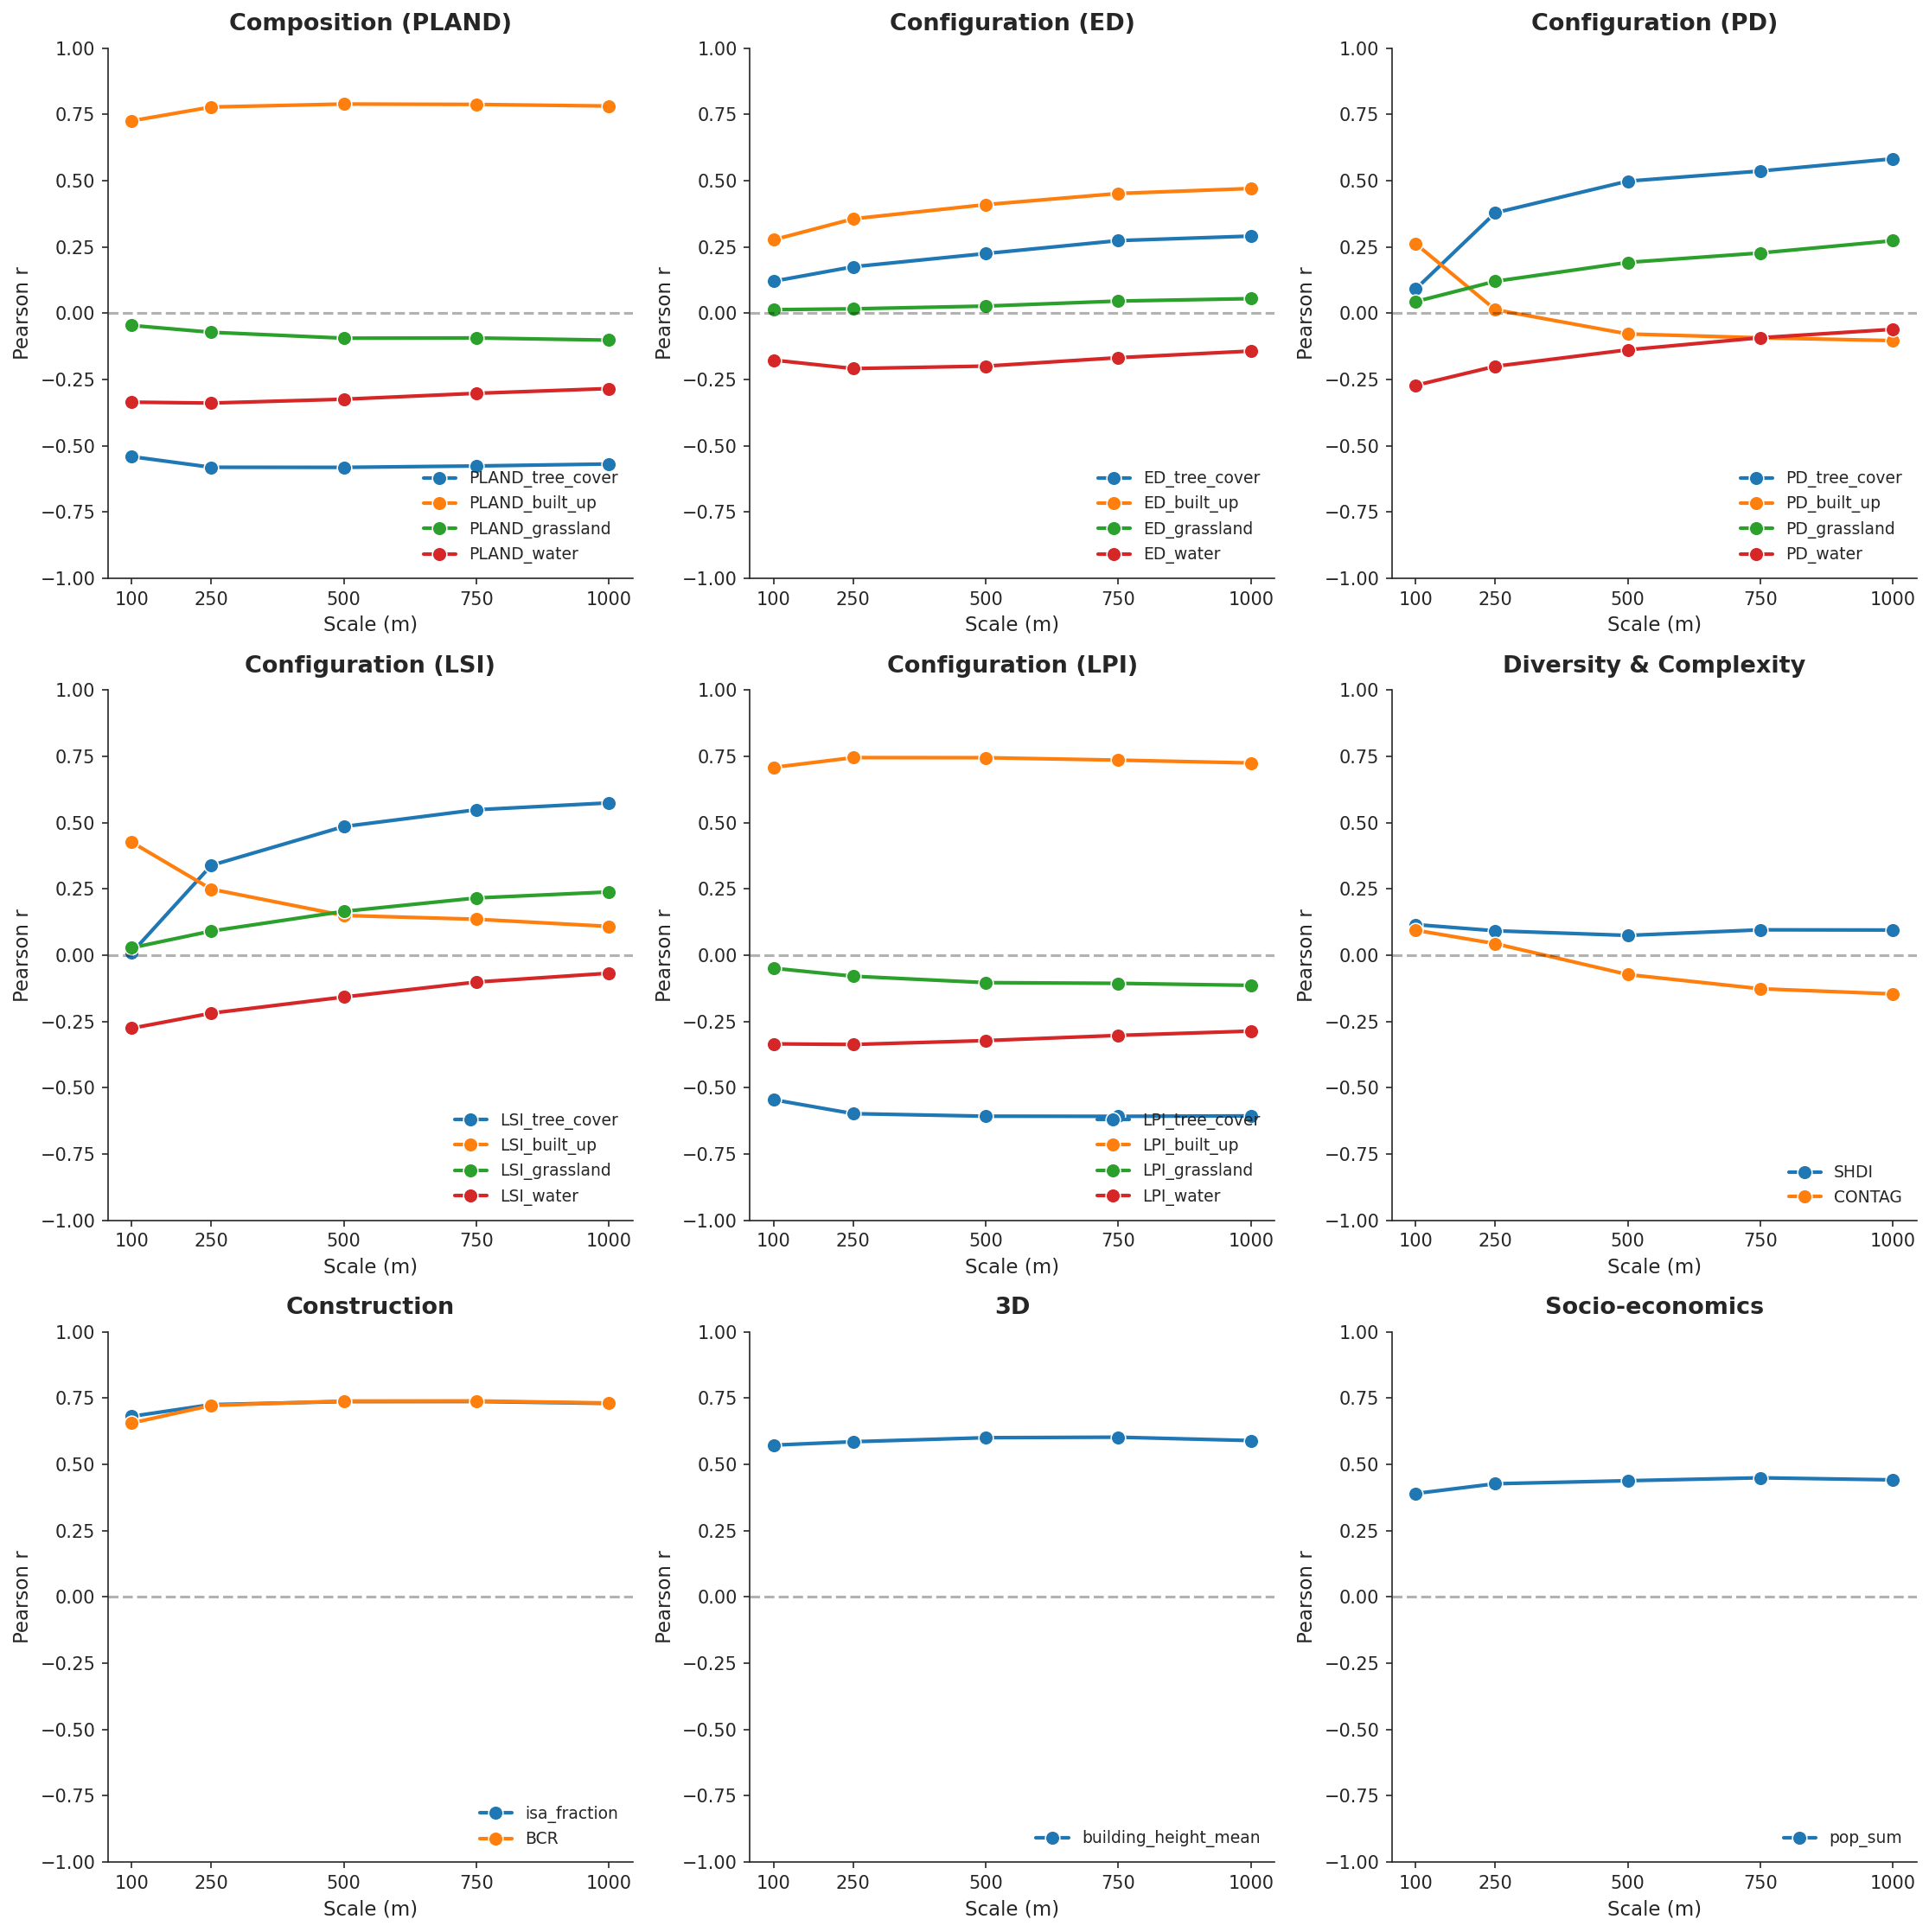

In [9]:
# 1. 配置路径和参数
GRID_SIZES = [100, 250, 500, 750, 1000]
UNIFIED_DIR = Path("../../data/unified_scale_matrices").resolve()
TARGET_VAR = "SUHI"  # 假设你的因变量列名
name_mapping_dict = {'10': 'tree_cover', 
                     '20': 'shrubland',
                     '30': 'grassland',
                     '40': 'cropland',
                     '50': 'built_up',
                     '60': 'bare_land',
                     '70': 'snow_and_ice',
                     '80': 'water',
                     '90': 'wetland'}

# 你想要重点观察的变量列表 (包含核心研究变量和新加入的复杂性变量)
SELECTED_FEATURES = [
    "PLAND_tree_cover", "PLAND_built_up", "PLAND_grassland", "PLAND_water",
    "ED_tree_cover", "ED_built_up", "ED_grassland", "ED_water",
    "PD_tree_cover", "PD_built_up", "PD_grassland", "PD_water",
    "LSI_tree_cover", "LSI_built_up", "LSI_grassland", "LSI_water",
    "LPI_tree_cover", "LPI_built_up", "LPI_grassland", "LPI_water",
    "SHDI", "CONTAG", 
    "isa_fraction", "building_height_mean", "pop_sum", "BCR"
]
feature_groups = {"Composition (PLAND)": ["PLAND_tree_cover", "PLAND_built_up", "PLAND_grassland", "PLAND_water"],
                  "Configuration (ED)": ["ED_tree_cover", "ED_built_up", "ED_grassland", "ED_water"],
                  "Configuration (PD)": ["PD_tree_cover", "PD_built_up", "PD_grassland", "PD_water"],
                  "Configuration (LSI)": ["LSI_tree_cover", "LSI_built_up", "LSI_grassland", "LSI_water"],
                  "Configuration (LPI)": ["LPI_tree_cover", "LPI_built_up", "LPI_grassland", "LPI_water"],
                  "Diversity & Complexity": ["SHDI", "CONTAG"],
                  "Construction": ["isa_fraction", "BCR"],
                  "3D": ["building_height_mean"],
                  "Socio-economics": ["pop_sum"]}

# 2. 循环处理不同尺度的数据
results = []

for scale in GRID_SIZES:
    file_path = UNIFIED_DIR / f"merged_metrics_{scale}m.parquet"
    if not file_path.exists():
        print(f"Warning: {file_path} not found.")
        continue
        
    # 加载数据
    df = pd.read_parquet(file_path)
    new_column_names = {}
    for old_name in df.columns:
        if '_cls_' in old_name:
            suffix = old_name.split('_cls_')[-1]
            new_suffix = name_mapping_dict.get(suffix, suffix)  # 如果找不到映射，保留原样
            new_name = old_name.replace(f'_cls_{suffix}', f'_{new_suffix}')
            new_column_names[old_name] = new_name


    df = df.rename(columns=new_column_names)
    
    # 清理数据：确保包含目标变量和特征，并处理空值
    cols_to_use = [TARGET_VAR] + [f for f in SELECTED_FEATURES if f in df.columns]
    df_clean = df[cols_to_use].dropna()
    
    # 计算每个特征与 SUHI 的相关性和 P 值
    for feature in SELECTED_FEATURES:
        if feature in df_clean.columns:
            r_val, p_val = pearsonr(df_clean[feature], df_clean[TARGET_VAR])
            results.append({
                "Scale": scale,
                "Feature": feature,
                "Correlation": r_val,
                "P_value": p_val,
                "Is_Significant": p_val < 0.05
            })

# 3. 转换为 DataFrame 方便绘图
plot_df = pd.DataFrame(results)

# 4. 绘图逻辑
# 2. 设置列数和计算行数
cols = 3
rows = math.ceil(len(feature_groups) / cols)

# 3. 创建画布
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15, 5 * rows), dpi=150)
sns.set_style("ticks")
sns.despine()

# 重要：将二维 axes 数组扁平化，方便用单索引 i 访问
axes_flat = axes.flatten()

# 4. 循环绘图
for i, (group_name, features) in enumerate(feature_groups.items()):
    ax = axes_flat[i]
    
    # 筛选数据
    group_data = plot_df[plot_df["Feature"].isin(features)]
    
    if not group_data.empty:
        sns.lineplot(data=group_data, x="Scale", y="Correlation", hue="Feature", 
                     marker="o", ax=ax, linewidth=2, markersize=8)
        
        # 装饰子图
        ax.axhline(0, color='black', linestyle='--', alpha=0.3)
        ax.set_title(group_name, fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel("Pearson r", fontsize=11)
        ax.set_xlabel("Scale (m)", fontsize=11)
        ax.set_xticks(GRID_SIZES)
        ax.set_ylim(-1, 1) # 统一 Y 轴量程以便横向对比
        
        # 图例放在子图内（防止网格布局下外部图例重叠）
        ax.legend(fontsize=9, loc='lower right', frameon=False)

# 5. 隐藏多余的子图 (如果有的话)
# 比如 5 个分组放在 2x3 的网格里，第 6 个子图就是空的
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
# plt.savefig("multi_panel_scale_sensitivity.png", bbox_inches='tight')
plt.show()

/tmp/ipykernel_947886/3429727094.py:102: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.lineplot(data=df_sig, x="Scale", y="Correlation", hue="Feature",
/tmp/ipykernel_947886/3429727094.py:102: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.lineplot(data=df_sig, x="Scale", y="Correlation", hue="Feature",
/tmp/ipykernel_947886/3429727094.py:102: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.lineplot(data=df_sig, x="Scale", y="Correlation", hue="Feature",
/tmp/ipykernel_947886/3429727094.py:102: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.lineplot(data=df_sig, x="Scale", y="Correlation", hue="Feature",
/tmp/ipykernel_947886/3429727094.py:102: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.lineplot(data=df_sig, x="Scale", y=

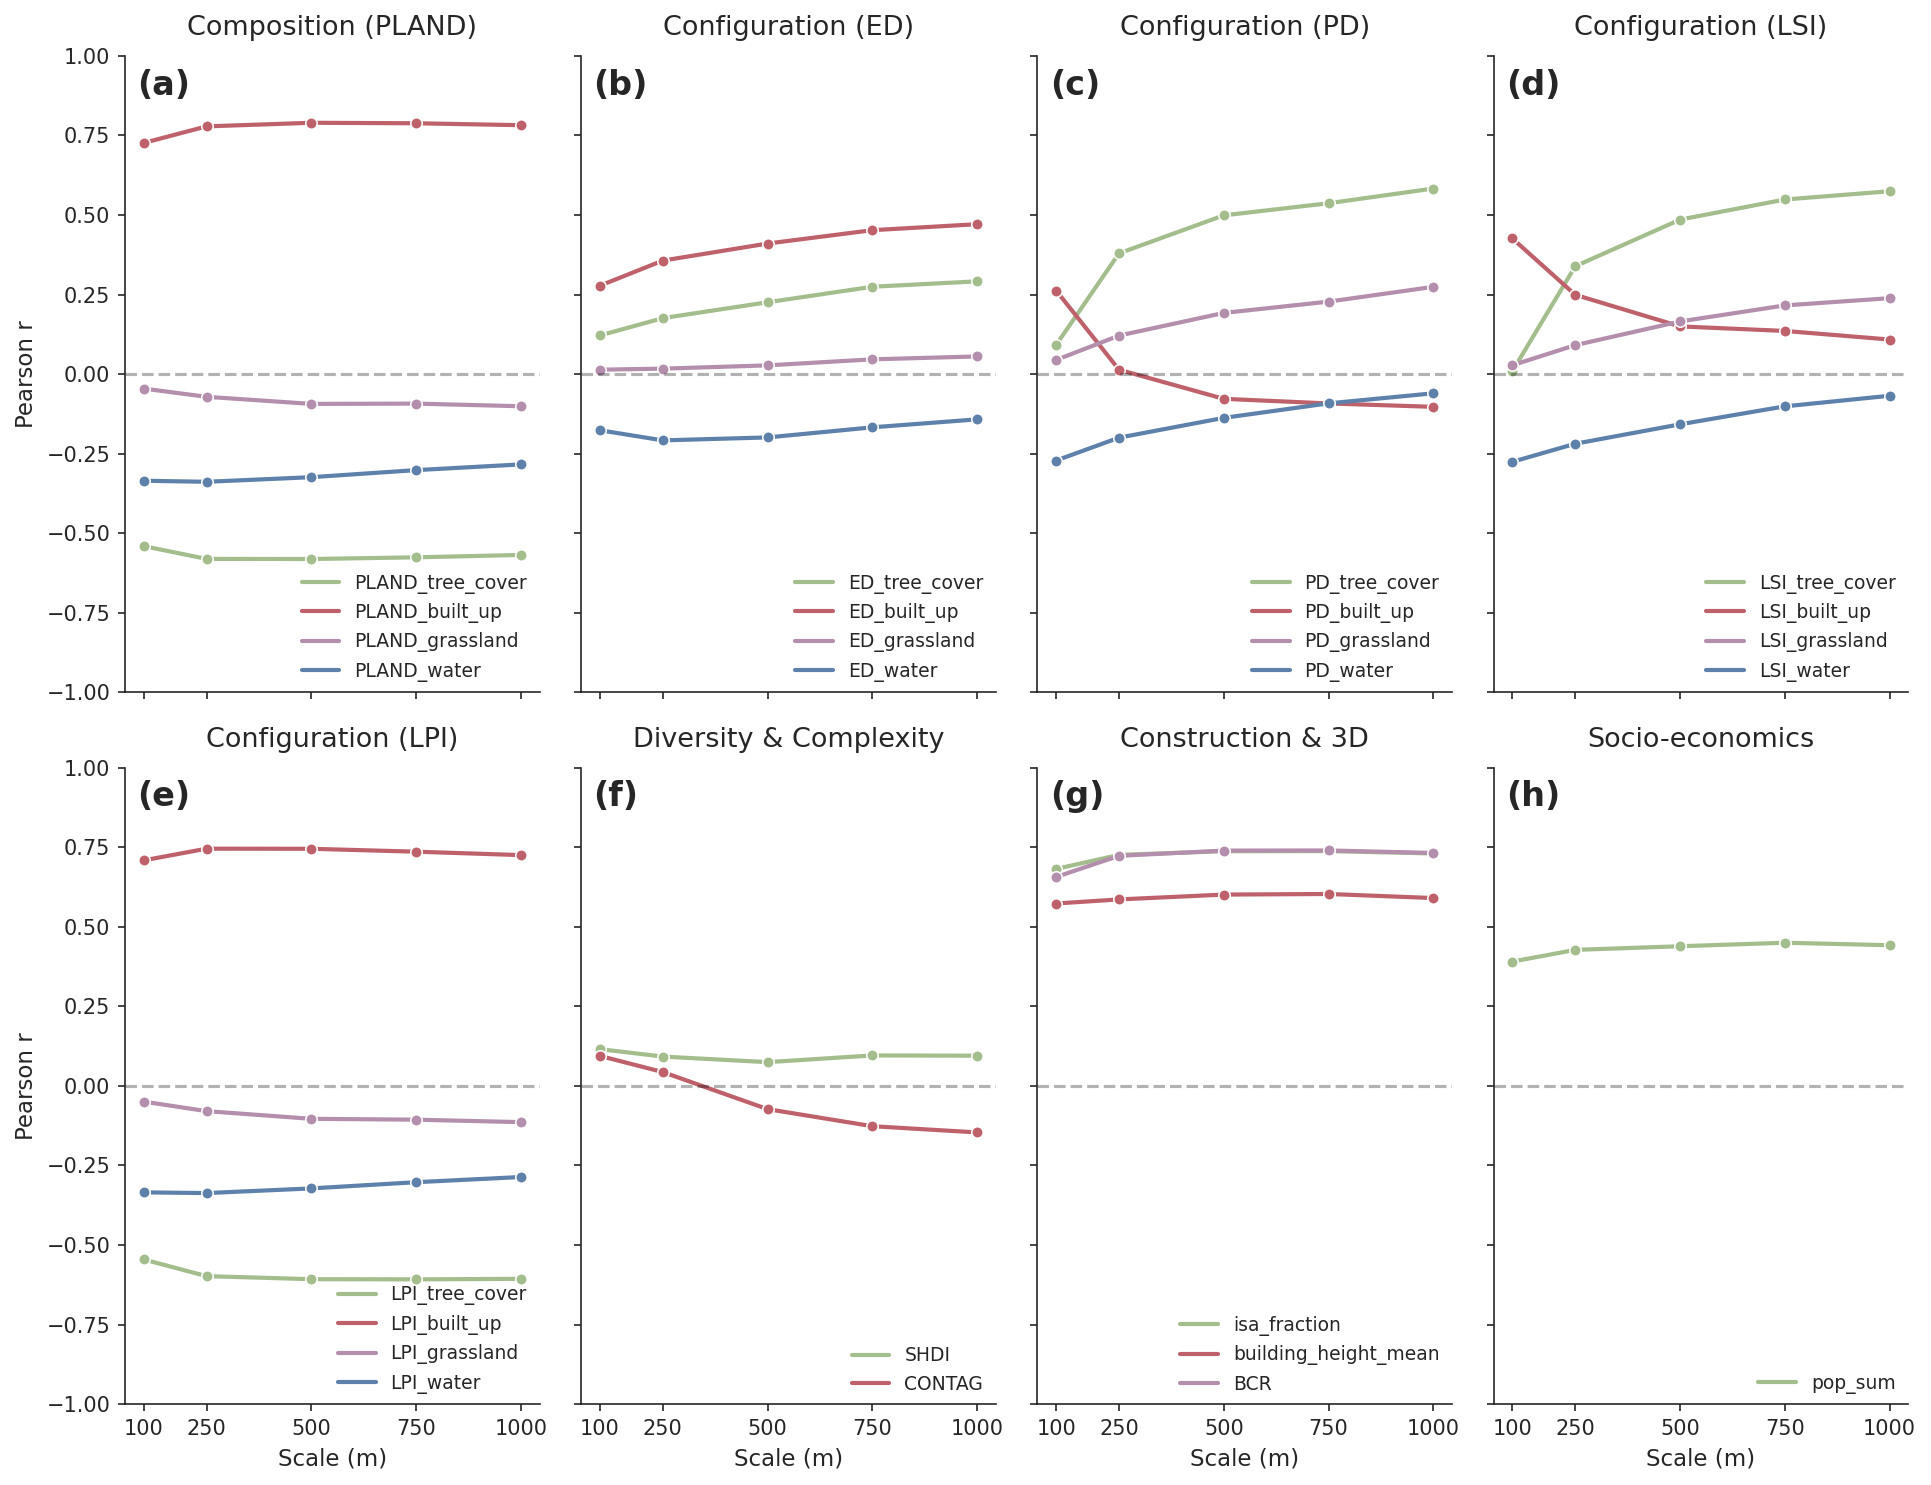

In [46]:
# 1. 配置路径和参数
GRID_SIZES = [100, 250, 500, 750, 1000]
UNIFIED_DIR = Path("../../data/unified_scale_matrices").resolve()
TARGET_VAR = "SUHI"  # 假设你的因变量列名
name_mapping_dict = {'10': 'tree_cover', 
                     '20': 'shrubland',
                     '30': 'grassland',
                     '40': 'cropland',
                     '50': 'built_up',
                     '60': 'bare_land',
                     '70': 'snow_and_ice',
                     '80': 'water',
                     '90': 'wetland'}

# 你想要重点观察的变量列表 (包含核心研究变量和新加入的复杂性变量)
SELECTED_FEATURES = [
    "PLAND_tree_cover", "PLAND_built_up", "PLAND_grassland", "PLAND_water",
    "ED_tree_cover", "ED_built_up", "ED_grassland", "ED_water",
    "PD_tree_cover", "PD_built_up", "PD_grassland", "PD_water",
    "LSI_tree_cover", "LSI_built_up", "LSI_grassland", "LSI_water",
    "LPI_tree_cover", "LPI_built_up", "LPI_grassland", "LPI_water",
    "SHDI", "CONTAG", 
    "isa_fraction", "building_height_mean", "pop_sum", "BCR"
]
feature_groups = {"Composition (PLAND)": ["PLAND_tree_cover", "PLAND_built_up", "PLAND_grassland", "PLAND_water"],
                  "Configuration (ED)": ["ED_tree_cover", "ED_built_up", "ED_grassland", "ED_water"],
                  "Configuration (PD)": ["PD_tree_cover", "PD_built_up", "PD_grassland", "PD_water"],
                  "Configuration (LSI)": ["LSI_tree_cover", "LSI_built_up", "LSI_grassland", "LSI_water"],
                  "Configuration (LPI)": ["LPI_tree_cover", "LPI_built_up", "LPI_grassland", "LPI_water"],
                  "Diversity & Complexity": ["SHDI", "CONTAG"],
                  "Construction & 3D": ["isa_fraction", "BCR", "building_height_mean"],
                  "Socio-economics": ["pop_sum"]}

# 2. 循环处理不同尺度的数据
results = []

for scale in GRID_SIZES:
    file_path = UNIFIED_DIR / f"merged_metrics_{scale}m.parquet"
    if not file_path.exists():
        print(f"Warning: {file_path} not found.")
        continue
        
    # 加载数据
    df = pd.read_parquet(file_path)
    new_column_names = {}
    for old_name in df.columns:
        if '_cls_' in old_name:
            suffix = old_name.split('_cls_')[-1]
            new_suffix = name_mapping_dict.get(suffix, suffix)  # 如果找不到映射，保留原样
            new_name = old_name.replace(f'_cls_{suffix}', f'_{new_suffix}')
            new_column_names[old_name] = new_name


    df = df.rename(columns=new_column_names)
    
    # 清理数据：确保包含目标变量和特征，并处理空值
    cols_to_use = [TARGET_VAR] + [f for f in SELECTED_FEATURES if f in df.columns]
    df_clean = df[cols_to_use].dropna()
    
    # 计算每个特征与 SUHI 的相关性和 P 值
    for feature in SELECTED_FEATURES:
        if feature in df_clean.columns:
            r_val, p_val = pearsonr(df_clean[feature], df_clean[TARGET_VAR])
            results.append({
                "Scale": scale,
                "Feature": feature,
                "Correlation": r_val,
                "P_value": p_val,
                "Is_Significant": p_val < 0.05
            })

# 3. 转换为 DataFrame 方便绘图
plot_df = pd.DataFrame(results)
MORANDI_PALETTE = ["#A3BE8C", "#BF616A", "#B48EAD", "#5E81AC", "#D08770"]
sns.set_palette(MORANDI_PALETTE)
# 4. 绘图逻辑
# 2. 设置列数和计算行数
cols = 4
rows = math.ceil(len(feature_groups) / cols)

# 3. 创建画布
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(13, 5 * rows), dpi=150)
sns.set_style("ticks")

# 重要：将二维 axes 数组扁平化，方便用单索引 i 访问
axes_flat = axes.flatten()
sub_labels = list(string.ascii_lowercase)

for i, (group_name, features) in enumerate(feature_groups.items()):
    ax = axes_flat[i]
    row_idx = i // cols
    col_idx = i % cols
    
    group_data = plot_df[plot_df["Feature"].isin(features)]
    
    if not group_data.empty:
        # 分离显著/不显著：显著保持原样，不显著用灰色虚线弱化显示
        df_sig = group_data[group_data['Is_Significant'] == True]
        df_nonsig = group_data[group_data['Is_Significant'] == False]

        if not df_sig.empty:
            sns.lineplot(data=df_sig, x="Scale", y="Correlation", hue="Feature", 
                         marker="o", ax=ax, palette=MORANDI_PALETTE, linewidth=2, markersize=5.5)

        # 将不显著的变量绘制为灰色虚线（不加入图例以保持简洁）
        if not df_nonsig.empty:
            for feat, sub in df_nonsig.groupby("Feature"):
                ax.plot(sub['Scale'], sub['Correlation'], linestyle='--', marker='o', markersize=4, color='0.6', alpha=0.7)

        ax.axhline(0, color='black', linestyle='--', alpha=0.3)
        ax.set_title(group_name, fontsize=13, pad=10)
        ax.set_xticks(GRID_SIZES)
        ax.set_ylim(-1, 1)
        
        # =================================================================
        # 🔬 科学定位：在子图左上角自动钉上 (a), (b), (c) 序号
        # =================================================================
        # transform=ax.transAxes 表示使用 [0, 1] 的子图相对坐标系
        # x=0.03, y=0.93 是经过严谨测试的左上角微调内边距
        ax.text(0.03, 0.98, f"({sub_labels[i]})", 
                transform=ax.transAxes, 
                fontsize=16, 
                fontweight='bold', 
                va='top', 
                ha='left',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)) # 加个半透明微型白底，防止被高空折线图遮挡
        # =================================================================
        
        # 共享坐标轴拦截
        if col_idx == 0:
            ax.set_ylabel("Pearson r", fontsize=11)
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])
            
        is_last_row = (row_idx == rows - 1)
        has_no_sub_plot_below = (i + cols >= len(feature_groups))
        
        if is_last_row or has_no_sub_plot_below:
            ax.set_xlabel("Scale (m)", fontsize=11)
        else:
            ax.set_xlabel("")
            ax.set_xticklabels([]) 
            
        # 图例仅显示显著变量，去掉图例圆点
        leg = ax.legend(fontsize=9, loc='lower right', frameon=False)
        if leg is not None:
            for handle in leg.legend_handles:
                handle.set_marker('None')
            leg.set_bbox_to_anchor((1.01, -0.01))  # 调整图例位置，向下移动一点

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

sns.despine()
plt.tight_layout()

# 物理落盘推荐：高分辨率存盘，可以直接扔进 LaTeX 论文中
# plt.savefig("multi_panel_scale_sensitivity_abc.png", bbox_inches='tight', dpi=300)
plt.show()


In [47]:
# Summary: report non-significant correlations
# If no output here differs from the previous plot, then all shown curves are significant
ns_df = plot_df[plot_df['Is_Significant'] == False]
total_nonsig = len(ns_df)

if total_nonsig == 0:
    print('All plotted feature-scale correlations are significant (p < 0.05).')
else:
    print(f'Total non-significant feature-scale pairs: {total_nonsig}')
    print('\nNon-significant counts by feature:')
    print(ns_df.groupby('Feature').size().sort_values(ascending=False))


All plotted feature-scale correlations are significant (p < 0.05).
